In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("credit_default_preprocessed.csv")
sns.set_style("whitegrid")

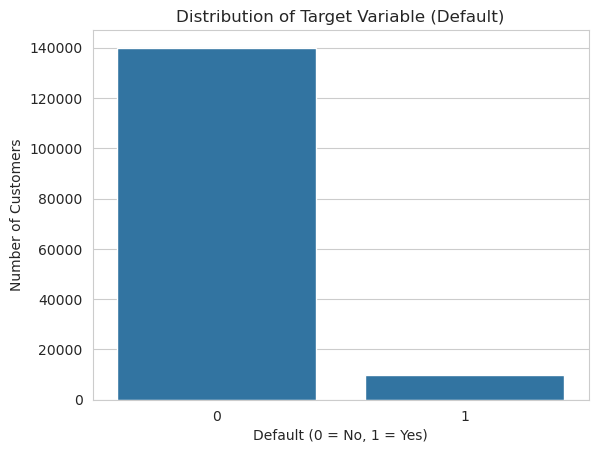

In [ ]:
plt.figure()
sns.countplot(x="Default", data=df)
plt.title("Distribution of Target Variable (Default)")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

'''check class imbalance in the dataset'''

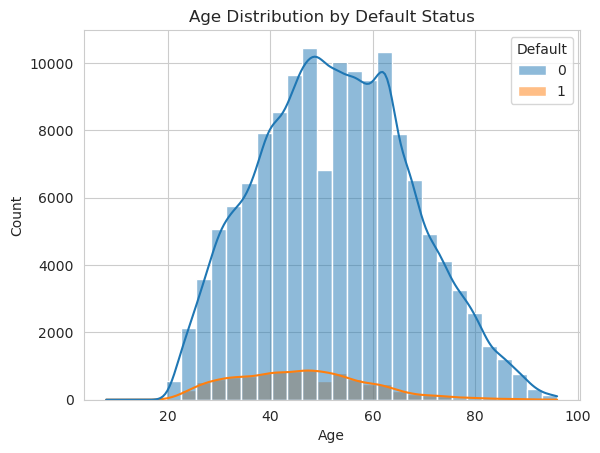

In [ ]:
plt.figure()
sns.histplot(data=df, x="Edad", hue="Default", bins=30, kde=True)
plt.title("Age Distribution by Default Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
'''Helps see if certain age group defaults more'''

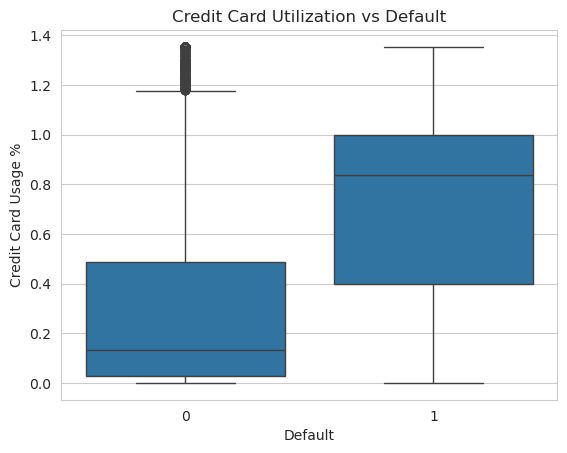

In [ ]:
plt.figure()
sns.boxplot(x="Default", y="Prct_uso_tc", data=df)
plt.title("Credit Card Utilization vs Default")
plt.xlabel("Default")
plt.ylabel("Credit Card Usage %")
plt.show()

'''Higher utilisation indicates financial stress'''

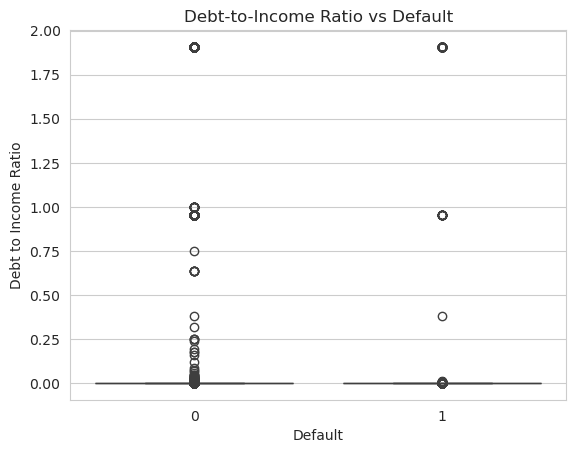

In [ ]:
plt.figure()
sns.boxplot(x="Default", y="Debt_to_Income", data=df)
plt.title("Debt-to-Income Ratio vs Default")
plt.xlabel("Default")
plt.ylabel("Debt to Income Ratio")
plt.show()
'''Higher ratio=greater risk of default'''

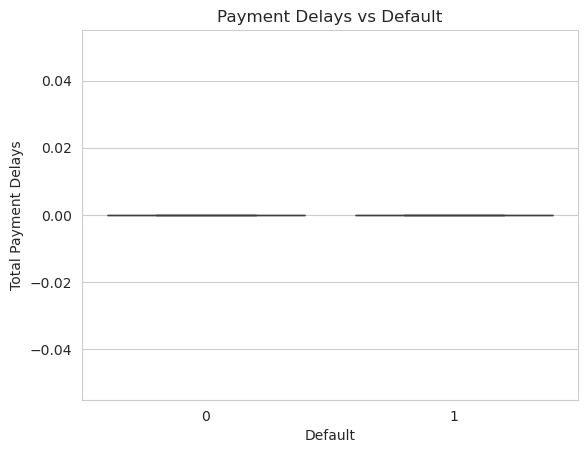

In [ ]:
plt.figure()
sns.boxplot(x="Default", y="Total_delays", data=df)
plt.title("Payment Delays vs Default")
plt.xlabel("Default")
plt.ylabel("Total Payment Delays")
plt.show()

'''Customers with more delays are more likely to default'''

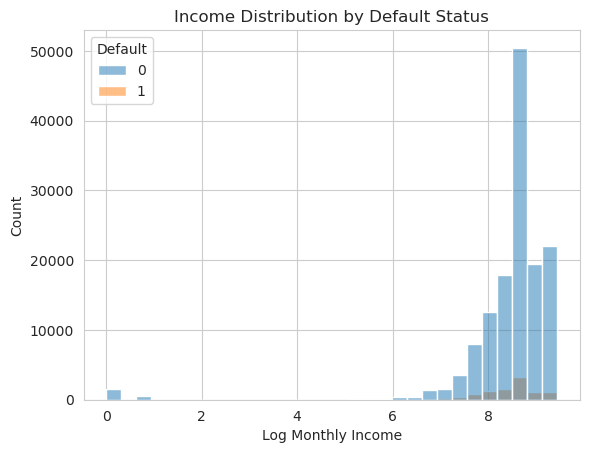

In [ ]:
plt.figure()
sns.histplot(data=df, x="Log_Mto_ingreso_mensual", hue="Default", bins=30)
plt.title("Income Distribution by Default Status")
plt.xlabel("Log Monthly Income")
plt.ylabel("Count")
plt.show()

'''see if lower income groups default more'''

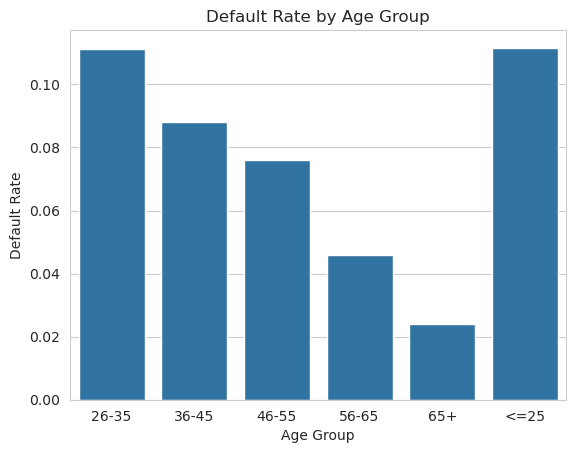

In [ ]:
plt.figure()
age_default = df.groupby("Age_bin")["Default"].mean().reset_index()

sns.barplot(x="Age_bin", y="Default", data=age_default)
plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate")
plt.show()

'''shows which age group has default probability'''

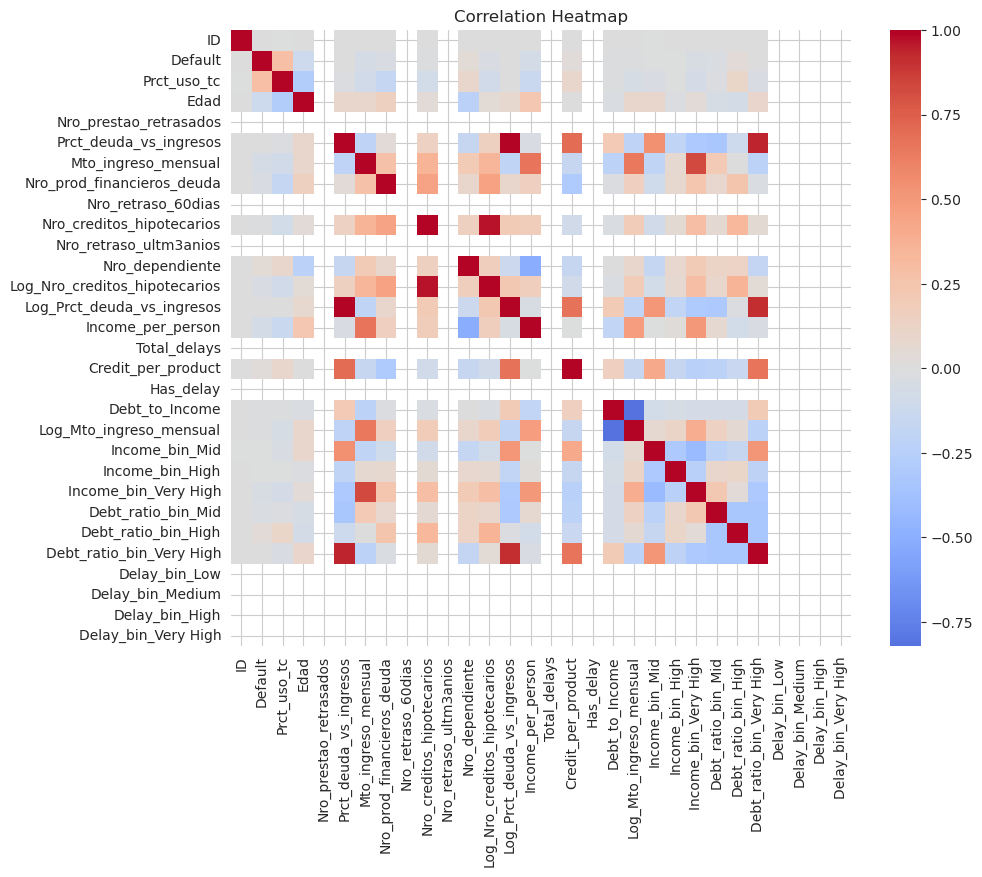

In [ ]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

'''helps identify variables most related to default'''

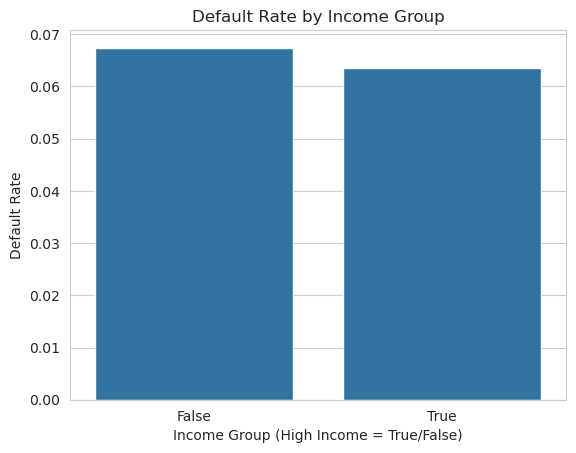

In [ ]:
plt.figure()

income_default = df.groupby("Income_bin_High")["Default"].mean().reset_index()

sns.barplot(x="Income_bin_High", y="Default", data=income_default)

plt.title("Default Rate by Income Group")
plt.xlabel("Income Group (High Income = True/False)")
plt.ylabel("Default Rate")

plt.show()

'''Low-income customers usually show higher default rates'''

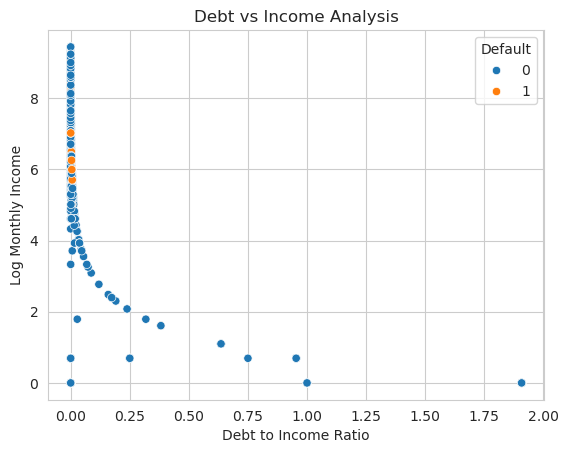

In [ ]:
plt.figure()

sns.scatterplot(
    x="Debt_to_Income",
    y="Log_Mto_ingreso_mensual",
    hue="Default",
    data=df
)

plt.title("Debt vs Income Analysis")
plt.xlabel("Debt to Income Ratio")
plt.ylabel("Log Monthly Income")

plt.show()
'''Defaulters often cluster where:

Debt is high

Income is low'''

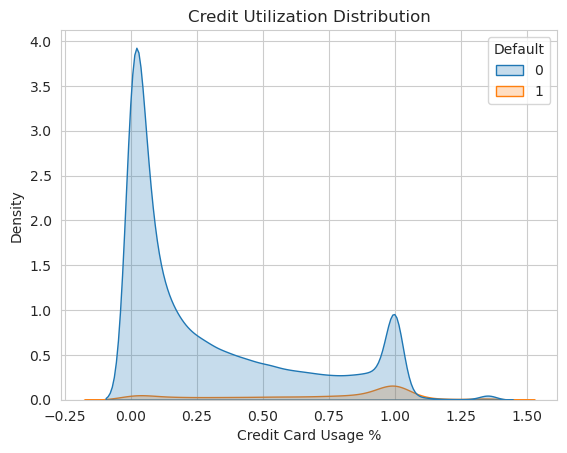

In [ ]:
plt.figure()

sns.kdeplot(
    data=df,
    x="Prct_uso_tc",
    hue="Default",
    fill=True
)

plt.title("Credit Utilization Distribution")
plt.xlabel("Credit Card Usage %")
plt.ylabel("Density")

plt.show()

'''Customers using 80-100% credit tend to default more'''

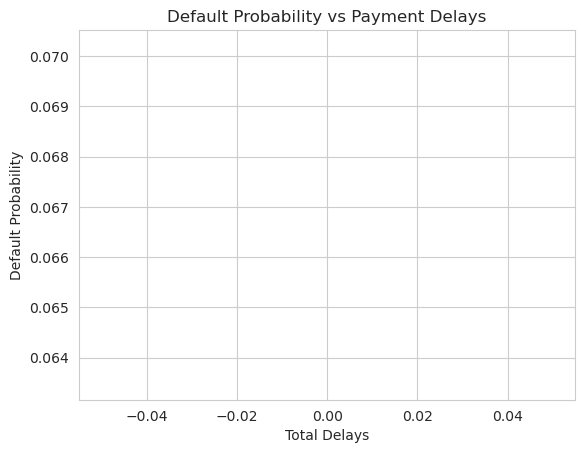

In [ ]:
plt.figure()

delay_default = df.groupby("Total_delays")["Default"].mean()

delay_default.plot()

plt.title("Default Probability vs Payment Delays")
plt.xlabel("Total Delays")
plt.ylabel("Default Probability")

plt.show()

'''default probability increases sharply with more payment delays'''

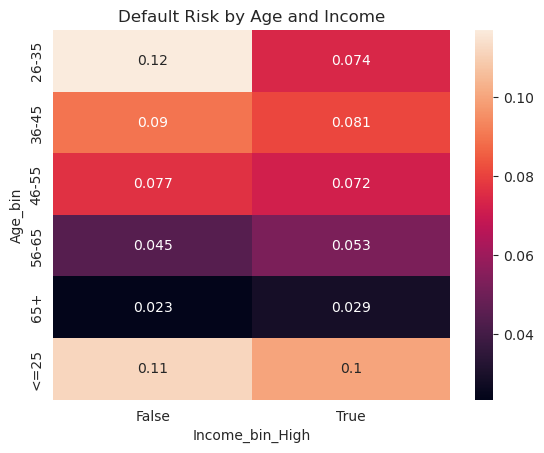

In [ ]:
plt.figure()

pivot = df.pivot_table(
    values="Default",
    index="Age_bin",
    columns="Income_bin_High",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True)

plt.title("Default Risk by Age and Income")

plt.show()

'''This visualization helps banks identify high-risk customer segments.'''